In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import statsmodels.formula.api as smf
import seaborn as sns
import statsmodels.api as sm
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

### Exercício 1

Exercício 1 - Determinar a probabilidade do usuário de comprar uma SUV, baseado em sua idade e salário.

#### Análise Descritiva

##### Lendo arquivo

In [7]:
dados = pd.read_csv('SUV_Network_ADS (3).csv')
dados.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


##### Dimensão do dataset

In [8]:
dados.shape

(400, 5)

##### Tipo dos dados

In [9]:
dados.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

##### Excluindo coluna User ID

In [21]:
dados.drop(columns=['User ID'], inplace=True)

##### Alterando tipo das variáveis

In [22]:
dados['Gender'] = dados['Gender'].astype('category')
dados.dtypes

Gender             category
Age                   int64
EstimatedSalary       int64
Purchased             int64
dtype: object

##### Contagem de nulos

In [23]:
dados.isna().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

##### Distribuição de idade do dataset

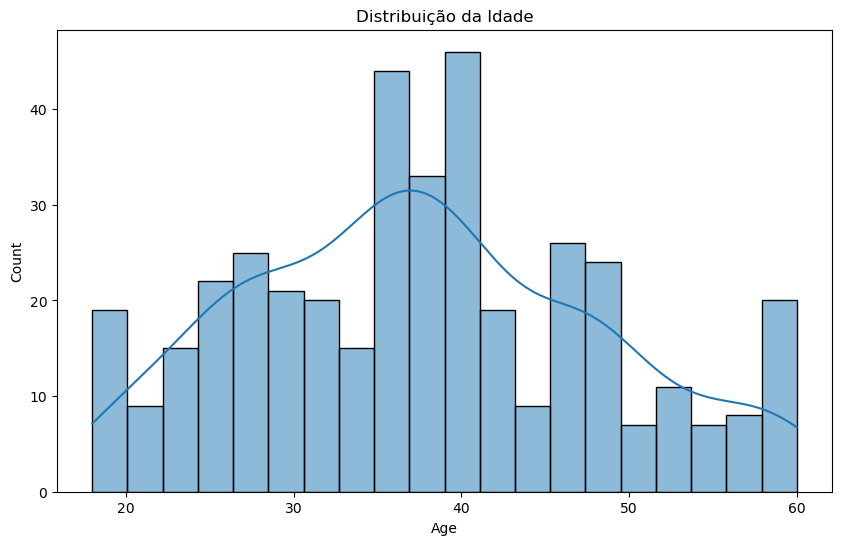

In [68]:
plt.figure(figsize=(10, 6))

sns.histplot(dados['Age'], bins=20, kde=True)
plt.title('Distribuição da Idade');

##### Análise gráfica da variável "Gender"

In [69]:
grafico = px.pie(dados, names='Gender', title='Distribuição por Gênero')
grafico.show()

##### Separando bases por "Gender" para análise

In [70]:
dados_fem = dados[dados['Gender'] == 'Female']
dados_masc = dados[dados['Gender'] == 'Male']

##### Distribuição de idade por "Gender"

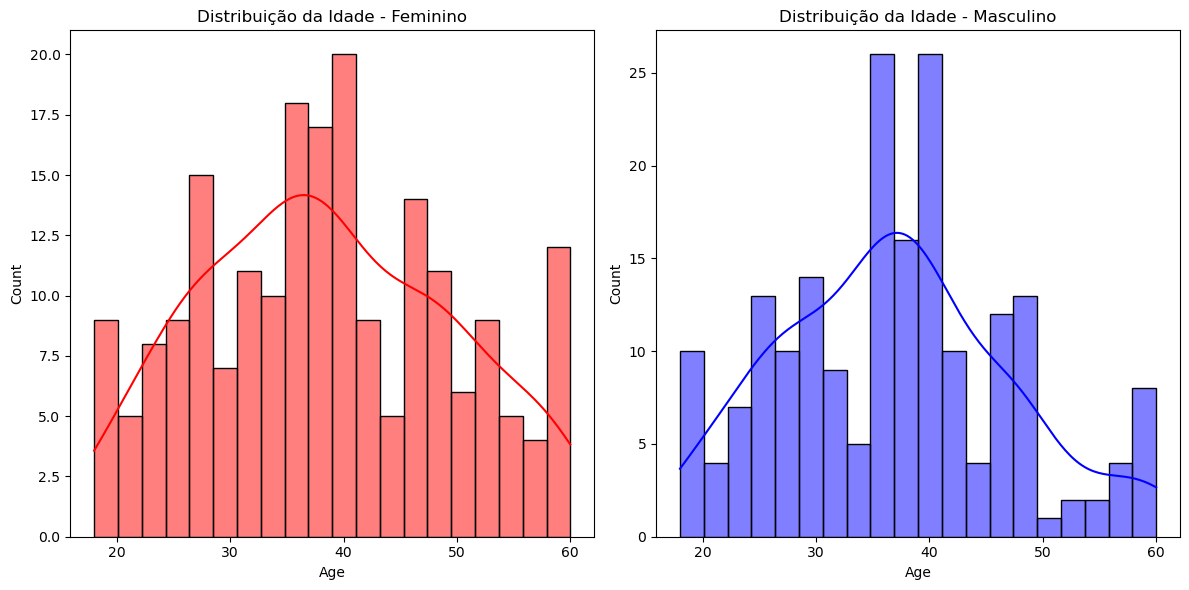

In [71]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(dados_fem['Age'], bins=20, kde=True, color='red')
plt.title('Distribuição da Idade - Feminino')
plt.subplot(1, 2, 2)
sns.histplot(dados_masc['Age'], bins=20, kde=True, color='blue')
plt.title('Distribuição da Idade - Masculino')
plt.tight_layout()
plt.show();

##### Distribuição de Salário por "Gender"

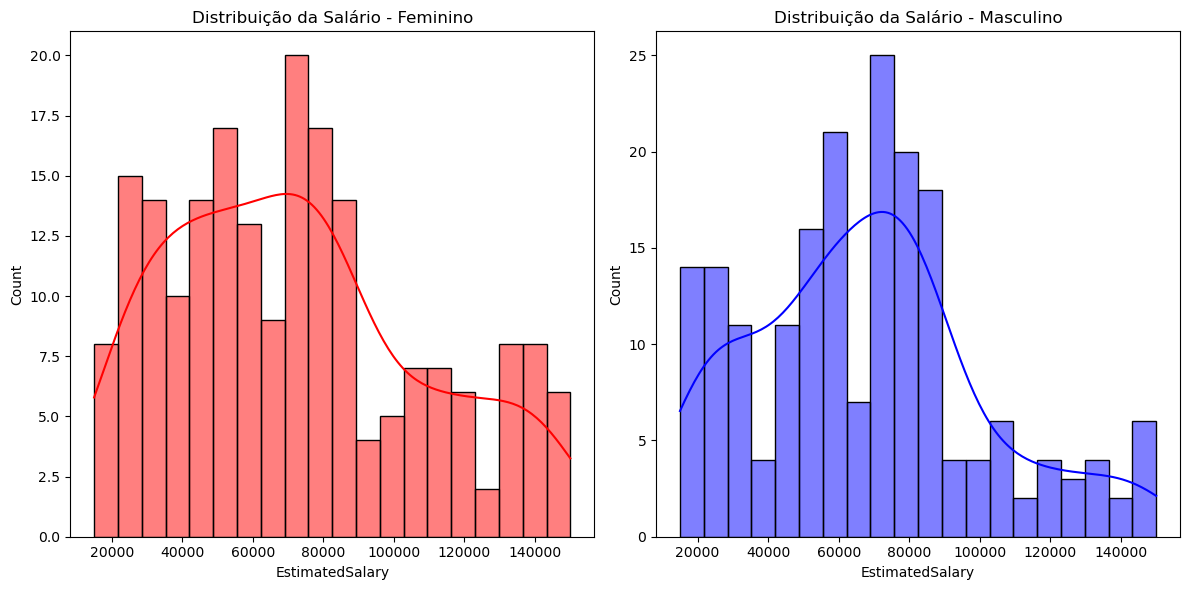

In [72]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(dados_fem['EstimatedSalary'], bins=20, kde=True, color='red')
plt.title('Distribuição da Salário - Feminino')
plt.subplot(1, 2, 2)
sns.histplot(dados_masc['EstimatedSalary'], bins=20, kde=True, color='blue')
plt.title('Distribuição da Salário - Masculino')
plt.tight_layout()
plt.show();

##### Boxplot do Salário

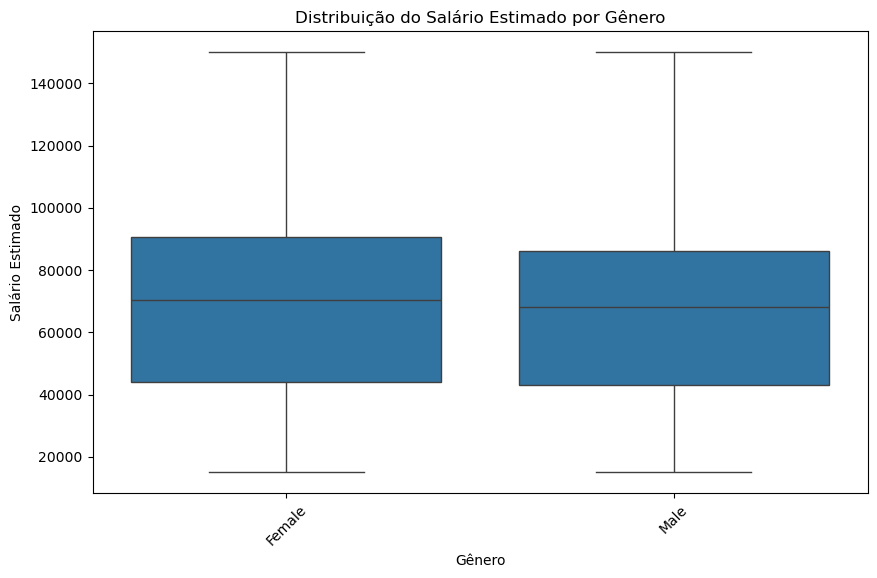

In [73]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='EstimatedSalary', data=dados)

plt.xlabel('Gênero')
plt.ylabel('Salário Estimado')
plt.title('Distribuição do Salário Estimado por Gênero')
plt.xticks(rotation=45)
plt.show()

##### Tabela descritiva dos dados

In [74]:
dados.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


##### Retirando a coluna "Gender"

In [81]:
dados2 = dados[['Age', 'EstimatedSalary', 'Purchased']]

##### Boxplot da variável "Age"

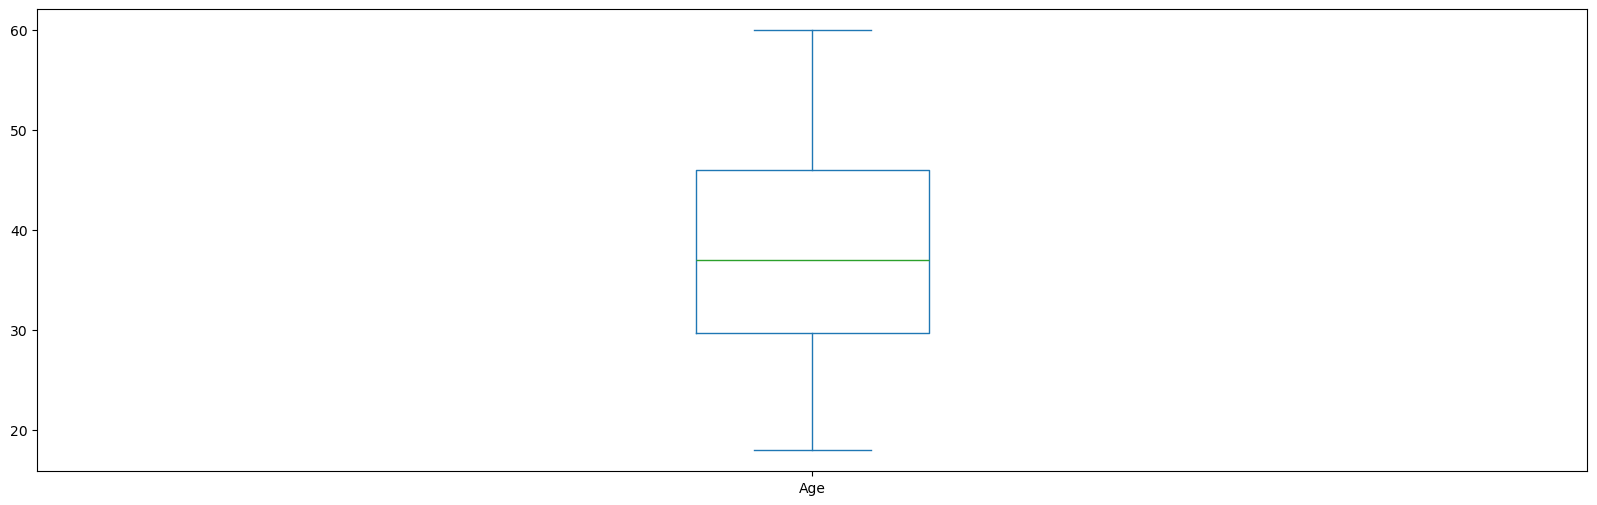

In [84]:
dados2['Age'].plot.box(figsize=(20,6))
plt.show()

##### Boxplot da variável "EstimatedSalary"

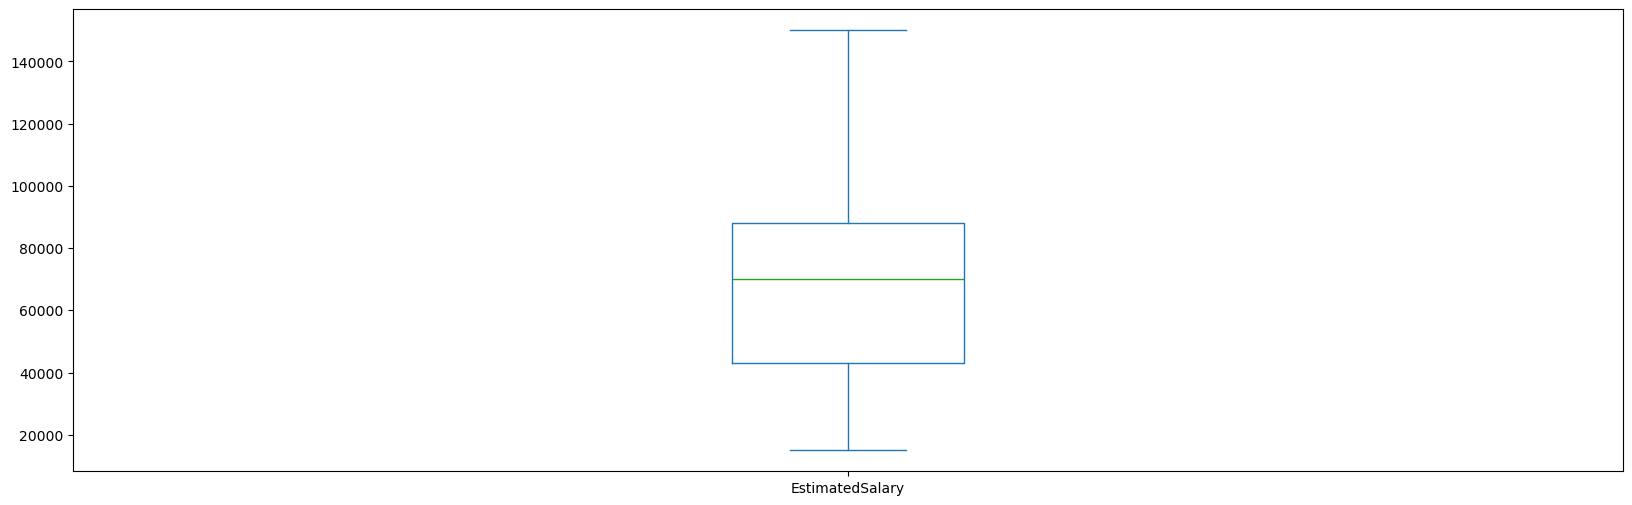

In [85]:
dados2['EstimatedSalary'].plot.box(figsize=(20,6))
plt.show()

##### Correlograma

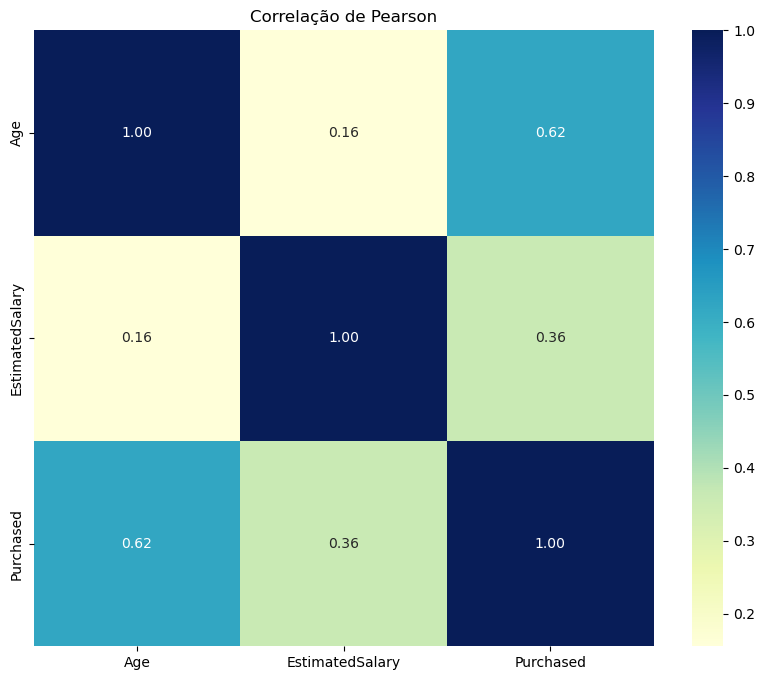

In [82]:
plt.figure(figsize=(10,8))
sns.heatmap(dados2.corr(), annot=True, cmap='YlGnBu', fmt='.2f');
plt.title('Correlação de Pearson')

plt.show()

In [88]:
X = dados2[['Age', 'EstimatedSalary']]
X = sm.add_constant(X)

vif_data = pd.DataFrame(
    {
        "Variável": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]    
    }
)

print(vif_data)

          Variável        VIF
0            const  16.209027
1              Age   1.024694
2  EstimatedSalary   1.024694


Valores menores que 5, indiciando ausência de multicolinearidade

#### Construção do modelo

##### Modelo Full

In [125]:
dados_base = dados.copy()
dados_base['Purchased'] = dados_base['Purchased'].astype('category').cat.reorder_categories([1, 0], ordered=False)

modelo_full = smf.glm(
    formula='Purchased ~ Age + EstimatedSalary', 
    data=dados_base, 
    family=sm.families.Binomial()
).fit()

print(modelo_full.summary())

                        Generalized Linear Model Regression Results                         
Dep. Variable:     ['Purchased[1]', 'Purchased[0]']   No. Observations:                  400
Model:                                          GLM   Df Residuals:                      397
Model Family:                              Binomial   Df Model:                            2
Link Function:                                Logit   Scale:                          1.0000
Method:                                        IRLS   Log-Likelihood:                -138.53
Date:                              Tue, 10 Mar 2026   Deviance:                       277.05
Time:                                      20:48:38   Pearson chi2:                     467.
No. Iterations:                                   6   Pseudo R-squ. (CS):             0.4574
Covariance Type:                          nonrobust                                         
                      coef    std err          z      P>|z|      [0.02

#### Teste da Razão de Verossimilhança (Likelihood Ratio Test - LR Test)  
  
$H_0$: O modelo nulo é tão bom quanto o modelo completo (as variáveis independentes não melhoram significativamente o ajuste do modelo).  
$H_1$: O modelo completo é significativamente melhor do que o modelo nulo (as variáveis independentes contribuem para explicar a variável resposta).

In [126]:
modelo_nulo = smf.glm(
    formula='Purchased ~ 1',
    data=dados,
    family=sm.families.Binomial()
).fit()

diff_ll = modelo_full.llf - modelo_nulo.llf

df = modelo_full.df_model - modelo_nulo.df_model

p_value = 1 - stats.chi2.cdf(diff_ll, df)

print('Teste de Razão de Verossimilhança:')
print('Estatística de teste:', diff_ll)
print('Graus de liberdade:', df)
print('Valor p:', p_value)

Teste de Razão de Verossimilhança:
Estatística de teste: 122.2607917022128
Graus de liberdade: 2
Valor p: 0.0


-   Em outras palavras, um p‑valor de zero (isto é, inferior a 0,05) leva à rejeição de $H_0$, havendo evidências de que o modelo que inclui todas as variáveis explica melhor os dados do que o modelo nulo sem preditores.

#### Teste de significância dos coeficientes do modelo - Teste de Wald

$H_0: β_i = 0$  
$H_1: β_i ≠ 0$

- Pelo teste de Wald, todas as variáveis são significativas para o modelo.

#### Teste de adequação do modelo - Resíduos Deviance

$H_0$: O modelo está bem ajustado aos dados.  
$H_1$: O modelo não está bem ajustado aos dados.

In [137]:
# Teste de Deviance para os Resíduos
deviance_test_statistic = modelo_full.deviance
deviance_df = modelo_full.df_resid
deviance_p_value = 1 - stats.chi2.cdf(deviance_test_statistic, deviance_df)

print('Teste de Deviance para os Resíduos:')
print('Estatística de teste:', deviance_test_statistic.round(3))
print('Valor-p:', deviance_p_value)

Teste de Deviance para os Resíduos:
Estatística de teste: 277.051
Valor-p: 0.9999990198090116


- O p-valor ~1 indica a não rejeição da hipótese nula, ou seja, o modelo está bem ajustado aos dados.

#### Teste de adequação do modelo - Qui-quadrado de Pearson

$H_0$: O modelo está bem ajustado aos dados.  
$H_1$: O modelo não está bem ajustado aos dados.

In [136]:
# Obtendo os resíduos de Pearson
residuos_pearson = modelo_full.resid_pearson

# Teste de Pearson para os Resíduos
pearson_test_statistic = np.sum(residuos_pearson**2)
pearson_df = len(residuos_pearson) - modelo_full.df_model - 1  # Graus de liberdade corrigidos
pearson_p_value = 1 - stats.chi2.cdf(pearson_test_statistic, pearson_df)

print('\nTeste de Pearson para os Resíduos:')
print('Estatística de teste:', pearson_test_statistic.round(3))
print('Valor-p:', pearson_p_value.round(5))


Teste de Pearson para os Resíduos:
Estatística de teste: 466.776
Valor-p: 0.00895


- Como p-valor < 0.05, rejeitamos H0

#### Análise de Resíduos

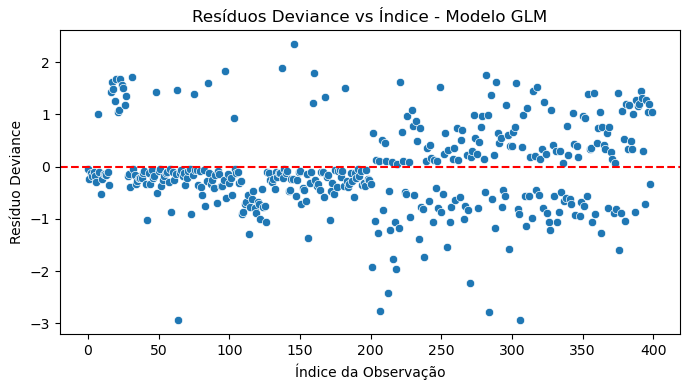

In [138]:
# Resíduos deviance
residuos_deviance = modelo_full.resid_deviance

# Resíduos de Pearson
residuos_pearson = modelo_full.resid_pearson

# Gráfico de Resíduos Deviance vs Índice
plt.figure(figsize=(7, 4))
sns.scatterplot(x=np.arange(len(residuos_deviance)), y=residuos_deviance)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos Deviance vs Índice - Modelo GLM')
plt.xlabel('Índice da Observação')
plt.ylabel('Resíduo Deviance')
plt.tight_layout()
plt.show()

In [151]:
fora_do_intervalo = residuos_deviance[(residuos_deviance > 2) | (residuos_deviance < -2)]
print(f'Resíduos fora do intervalo [-2, 2]: {len(fora_do_intervalo)}')

Resíduos fora do intervalo [-2, 2]: 7


A análise dos resíduos deviance, mostrou que a maioria dos valores estão dentro do intervalo aceitável [-2, 2], indicando um bom ajuste do modelo. Porém foram identificados sete resíduos com valores fora do intervalo aceitável, demonstrando observações de raro acontecimento.
A dispersão aleatória, demonstra que o modelo não possui padrões sistemáticos.

#### Curva ROC e Área Sob a Curva (AUC)

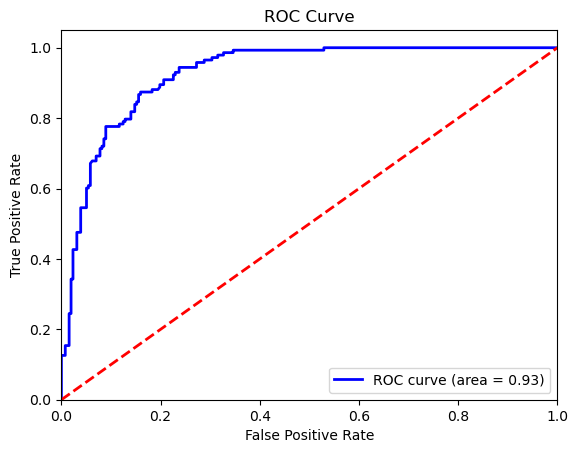

In [152]:
y = dados_base['Purchased']

# ROC Curve
fpr, tpr, _ = roc_curve(y, modelo_full.fittedvalues)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

A distância da curva ROC para a linha de referência, a curva ROC obteve AUC de 0.93, indicando excelente capacidade discriminatória do modelo. Isso significa que, em 93% das vezes, o modelo distingue corretamente um usuário que comprou a SUV de um que não comprou. A curva se afasta
expressivamente da linha de referência (AUC = 0.5), confirmando que Idade e Salário são preditores eficazes para a classificação binária, indicando que a capacidade da classificação binária, evidencia que o modelo desempenha satisfatoriamente as diferentes observações, tanto positivamente (Salário e Idade influenciam na compra de SUV), quanto negativamente (Salário e Idade não influenciam na compra de SUV).

#### Interpretação dos coeficientes do modelo

In [155]:
odds_ratios = np.exp(modelo_full.params)
conf_int = np.exp(modelo_full.conf_int())

print('Odds Ratios:')
print(odds_ratios)

conf_int_formatted = conf_int.apply(lambda x: f'[{x[0]:.3f}, {x[1]:.3f}]', axis=1)

result_df = pd.DataFrame({
    'Variável': odds_ratios.index,
    'Odds (Intervalo de Confiança)': [f'{odds:.3f}  {conf}' for odds, conf in zip(odds_ratios, conf_int_formatted)]
})

print(tabulate(result_df, headers='keys', tablefmt='plain', showindex=False))

Odds Ratios:
Intercept          0.000004
Age                1.262999
EstimatedSalary    1.000036
dtype: float64
Variável         Odds (Intervalo de Confiança)
Intercept        0.000  [0.000, 0.000]
Age              1.263  [1.200, 1.329]
EstimatedSalary  1.000  [1.000, 1.000]


In [156]:
np.exp(modelo_full.params['EstimatedSalary'] * 1000)

np.float64(1.0365531585497345)

AGE: A cada 1 ano a mais, a chance de comprar a SUV aumenta em 26%

EstimatedSalary: A cada R$1.000,00 a mais de salário, a chance de comprar a SUV aumenta em 3.7%.